# Labjournaal: Vibrating String Experiment
### Alejandro Jean & Rune Veraart

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

## Measurements

In [2]:
T345 = np.array([28, 30, 41, 48, 57, 70, 77, 90, 115]) # Celsius
u_T345 = 3 # Based on the uncertainty of the thermometer used in the experiment
eigen_f345 = np.array([350.4, 349.9, 349.2, 348.2, 347.2, 346.4, 344.5, 342.7 ,337.7]) # Hz
u_f345 = 8 # Based on the uncertainty of the Fast Fourier Transform (FFT) used in the experiment

T225 = np.array([27, 45, 60, 81, 91, 100, 129, 159, 174, 205, 236]) # Celsius
u_T225 = 3 # Based on the uncertainty of the thermometer used in the experiment
eigen_f225 = np.array([854.49, 842.28, 830.07, 817.87, 805.66, 799.56, 775.14, 769.04, 750.73, 720.21, 677.49]) # Hz
u_f225 = 8 # Based on the uncertainty of the Fast Fourier Transform (FFT) used in the experiment


T498 = np.array([27, 45, 64, 81, 115, 135, 155, 202, 263, 350, 450]) # Celsius
u_T498 = 3 # Based on the uncertainty of the thermometer used in the experiment
eigen_f498 = np.array([280.76, 268.55, 256.34, 244.14, 225.83, 207.51, 195.31, 177, 152.58, 109.86, 30.51]) # Hz
u_f498 = 8 # Based on the uncertainty of the Fast Fourier Transform (FFT) used in the experiment

## Constants & Functions

In [3]:
alpha_V = 32.4*(10**-6) #Thermal expansion coefficient of steel in respect to volume K^-1
alpha_L = 10.8*(10**-6)  #Thermal expansion coefficient of steel in respect to length K^-1 

# The diameter of the string used in the experiments was 0.5 mm
r = 0.0005 / 2 # m
A = np.pi * r ** 2 # m^2

di = 7900 #kg/m^3
r = 0.0005/2 #m 
u_r = 0.0001 #m
opp_oud = np.pi*r**2 
mu = di*opp_oud #kg/m

V = 1 # m^3
E = 200*(10**9) 
def frequentieF(l,T,mu,opp, t0):
    t = t0 - E * alpha_L * T * opp
    v = np.sqrt(t/mu)
    return (1*v/(2*l))

C:\Users\runev\AppData\Local\Temp\ipykernel_2208\56727650.py:18: RuntimeWarning: invalid value encountered in sqrt
  v = np.sqrt(t/mu)


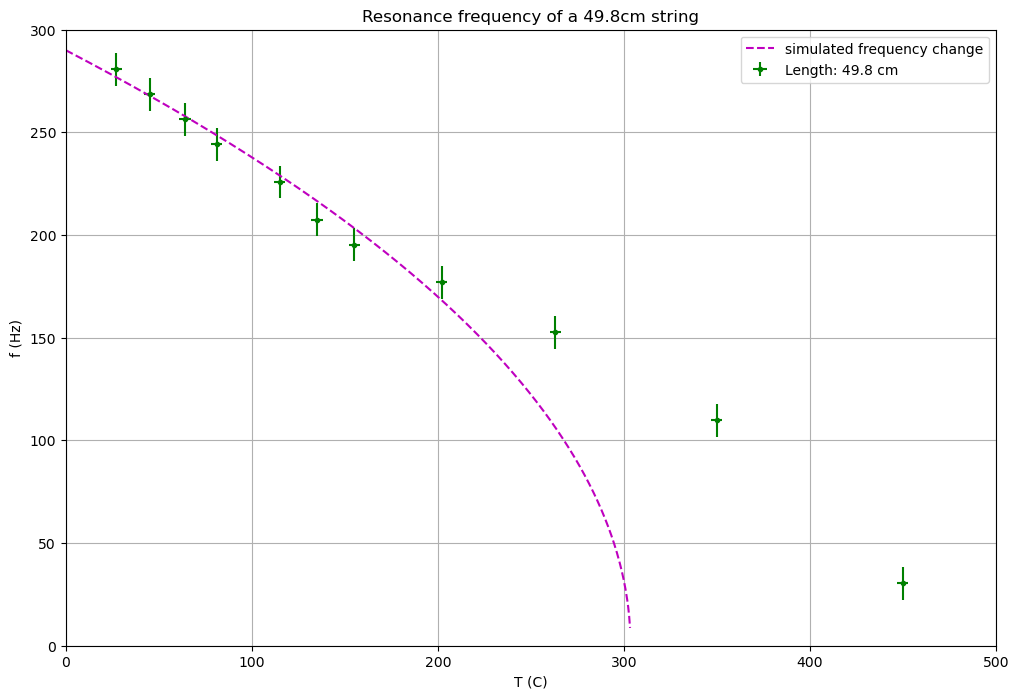

In [4]:
t1 = 118 #N
L498 = 0.498 #m
simT498 = np.linspace(0,500,1000)
calc_freq498 = np.array([])
for i in simT498:
    deltaT= i - 27 
    delta_r = r*deltaT*alpha_L
    new_r = r + delta_r
    new_opp = np.pi*new_r**2
    V_change = alpha_V*deltaT*V
    NewV = V_change + V
    New_di = di/NewV
    New_mu = New_di*new_opp
    new_freq = frequentieF(L498,deltaT,New_mu,new_opp,t1) 
    calc_freq498 = np.append(calc_freq498,new_freq)

plt.figure(figsize=[12, 8])
plt.errorbar(T498, eigen_f498, yerr=u_f498, xerr=u_T498, fmt='g.', ecolor='green', label="Length: 49.8 cm")
plt.plot(simT498,calc_freq498, "m--", label="simulated frequency change")
plt.xlim(0, 500)
plt.ylim(0, 300)
plt.xlabel("T (C)")
plt.ylabel("f (Hz)")
plt.title("Resonance frequency of a 49.8cm string")
plt.grid()
plt.legend()
plt.savefig("Frequency_vs_Temperature_49_8cm.png")
plt.show()

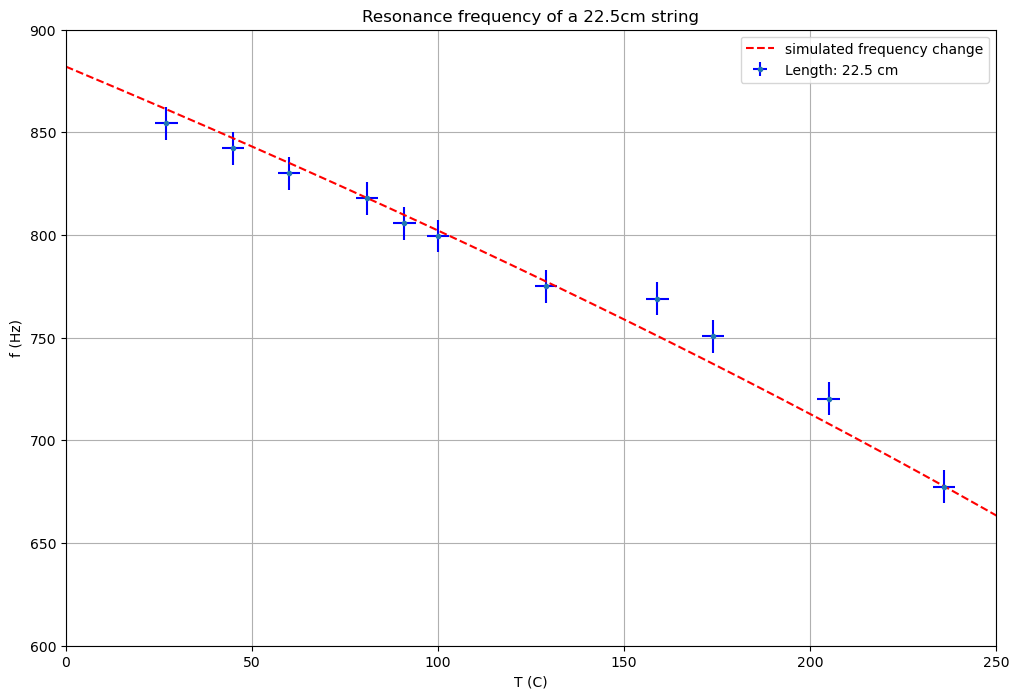

In [5]:
t2 = 233 #N 
L225 = 0.225 #m


simT225 = np.linspace(0,500,1000)
calc_freq225 = np.array([])
for i in simT225:
    deltaT= i - 27 
    delta_r = r*deltaT*alpha_L
    new_r = r + delta_r
    new_opp = np.pi*new_r**2
    V_change = alpha_V*deltaT*V
    NewV = V_change + V
    New_di = di/NewV
    New_mu = New_di*new_opp
    new_freq = frequentieF(L225,deltaT,New_mu,new_opp,t2) 
    calc_freq225 = np.append(calc_freq225,new_freq)

# Graph for the 22.5 cm string frequency change with temperature
plt.figure(figsize=[12, 8])
plt.errorbar(T225, eigen_f225, yerr=u_f225, xerr=u_T225, fmt='.', ecolor='blue', label="Length: 22.5 cm")
plt.plot(simT225,calc_freq225, "r--", label="simulated frequency change")
plt.xlim(0, 250)
plt.ylim(600, 900)
plt.xlabel("T (C)")
plt.ylabel("f (Hz)")
plt.title("Resonance frequency of a 22.5cm string")
plt.grid()
plt.legend()
plt.savefig("Frequency_vs_Temperature_22_5cm.png")
plt.show()

C:\Users\runev\AppData\Local\Temp\ipykernel_2208\56727650.py:18: RuntimeWarning: invalid value encountered in sqrt
  v = np.sqrt(t/mu)


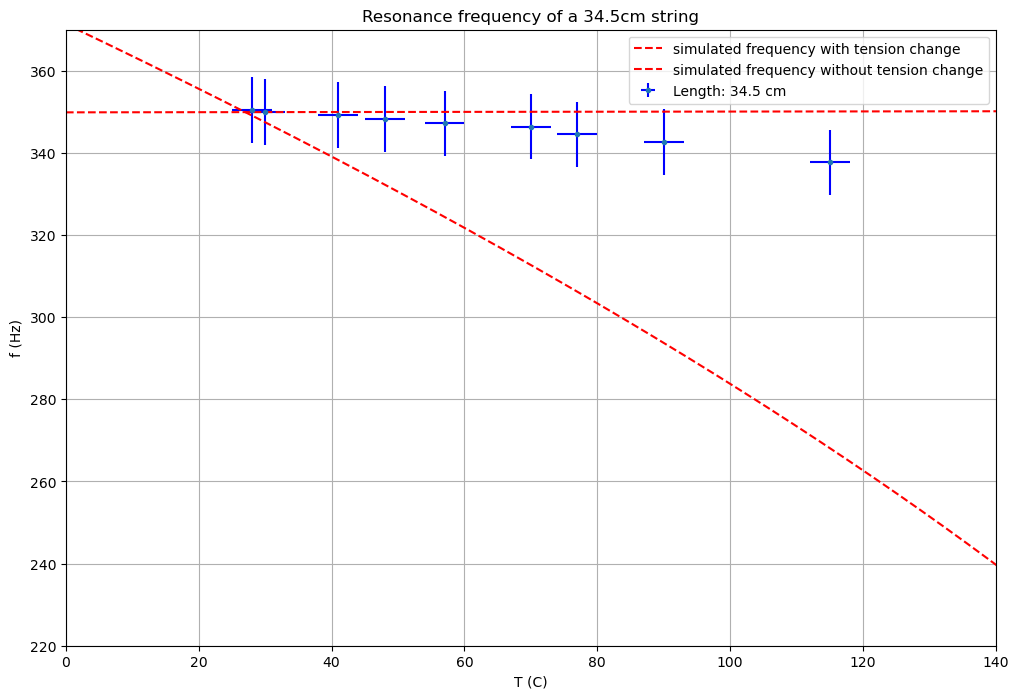

In [6]:
# The diameter of the string used in the experiments was 0.5 mm


di = 7900 #kg/m^3
r2 = 0.0009/2 #m 
A2 = np.pi * r2 ** 2 # m^2
u_r = 0.0001 #m
opp_oud = np.pi*r2**2 
mu = di*opp_oud #kg/m

def frequentie_muF(l,t,mu):
    v = np.sqrt(t/mu)
    return (1*v/(2*l))

t3 = 293 #N 
L345 = 0.345 #m
simT345 = np.linspace(0,500,1000)
calc_freq345 = np.array([])
calc_freq345_muF = np.array([])
for i in simT345:
    deltaT= i - 27 
    delta_r = r2*deltaT*alpha_L
    new_r = r2 + delta_r
    new_opp = np.pi*new_r**2
    V_change = alpha_V*deltaT*V
    NewV = V_change + V
    New_di = di/NewV
    New_mu = New_di*new_opp
    new_freq = frequentieF(L345,deltaT,New_mu,new_opp,t3) 
    new_freq_muF = frequentie_muF(L345,t3,New_mu)
    calc_freq345 = np.append(calc_freq345,new_freq)
    calc_freq345_muF = np.append(calc_freq345_muF,new_freq_muF)

plt.figure(figsize=[12, 8])
plt.errorbar(T345, eigen_f345, yerr=u_f345, xerr=u_T345, fmt='.', ecolor='blue',  label="Length: 34.5 cm")
plt.plot(simT345, calc_freq345, "r--", label="simulated frequency with tension change")
plt.plot(simT345, calc_freq345_muF, "r--", label="simulated frequency without tension change")
plt.xlim(0, 140)
plt.xlabel("T (C)")
plt.ylim(220,370)
plt.ylabel("f (Hz)")
plt.title("Resonance frequency of a 34.5cm string")
plt.grid()
plt.legend()
plt.savefig("Frequency_vs_Temperature_34_5cm.png")
plt.show()

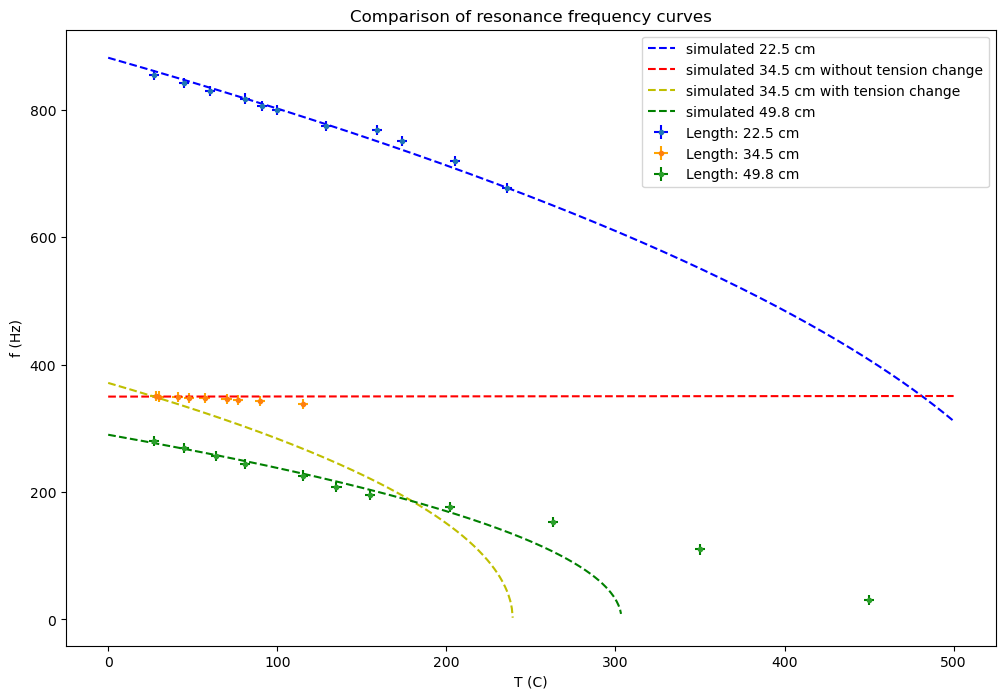

In [ ]:
plt.figure(figsize=[12, 8])
plt.errorbar(T225, eigen_f225, yerr=u_f225, xerr=u_T225, fmt='.', ecolor='blue', label="Length: 22.5 cm")
plt.plot(simT225,calc_freq225, "b--", label="simulated 22.5 cm")
plt.errorbar(T345, eigen_f345, yerr=u_f345, xerr=u_T345, fmt='.', ecolor='orange',  label="Length: 34.5 cm")
plt.plot(simT345, calc_freq345_muF, "r--", label="simulated 34.5 cm without tension change")
plt.plot(simT345, calc_freq345, "y--", label="simulated 34.5 cm w`§ith tension change")
plt.errorbar(T498, eigen_f498, yerr=u_f498, xerr=u_T498, fmt='.', ecolor='green', label="Length: 49.8 cm")
plt.plot(simT498,calc_freq498, "g--", label="simulated 49.8 cm")
plt.xlabel("T (C)")
plt.ylabel("f (Hz)")
plt.title("Comparison of resonance frequency curves")
plt.legend()
plt.savefig("Frequency_vs_Temperature_total.png")
plt.show()